In [ ]:
#imports only
from google.cloud import bigquery
from google.colab import auth
from scipy.stats import pearsonr

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Input, LSTM, GRU, Dropout,TimeDistributed
from keras.optimizers import SGD,Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
auth.authenticate_user()
print("Authenticated!!")

Authenticated!!


In [ ]:
project_id='smartwatts-project'

In [ ]:
#displays interactive dataframes can be ignored.
%load_ext google.colab.data_table
%reload_ext google.colab.data_table
print("Reloaded")

Reloaded


In [ ]:
#magic typing specifically for bigquery it since we only use the client once to get the data from BQ. we also name the dataset as df
%%bigquery df --project {project_id}
SELECT
  esiid, usage_hourly, usage_kwh,
  temp_f, humidity, wind_speed_mph,
  pressure_hpa, hour_of_day, day_of_week,
  month, year, is_weekend
FROM `smartwatts.mart`
ORDER BY esiid, usage_hourly

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
#verification df is saved correctly
print(df.shape)
print(df.dtypes)
print(df.head())


(209832, 12)
esiid                          object
usage_hourly      datetime64[us, UTC]
usage_kwh                     float64
temp_f                        float64
humidity                        Int64
wind_speed_mph                float64
pressure_hpa                  float64
hour_of_day                     Int64
day_of_week                     Int64
month                           Int64
year                            Int64
is_weekend                    boolean
dtype: object
  esiid              usage_hourly  usage_kwh  temp_f  humidity  \
0  Alfa 2022-10-04 00:00:00+00:00      1.616   82.94        27   
1  Alfa 2022-10-04 01:00:00+00:00      1.119   82.94        27   
2  Alfa 2022-10-04 02:00:00+00:00      1.067   81.14        32   
3  Alfa 2022-10-04 03:00:00+00:00      0.985   79.34        34   
4  Alfa 2022-10-04 04:00:00+00:00      1.227   77.54        39   

   wind_speed_mph  pressure_hpa  hour_of_day  day_of_week  month  year  \
0             8.1        1017.0            0  

In [ ]:
#seperates each essid in their own dataframe
esiid_data={esiid: group.copy() for esiid, group in df.groupby('esiid')}

for esiid, data in esiid_data.items():
  print(f"ESIID: {esiid}")
  print(data.head())
  print(f"Row count {len(data)}")
  print("\n")

ESIID: Alfa
  esiid              usage_hourly  usage_kwh  temp_f  humidity  \
0  Alfa 2022-10-04 00:00:00+00:00      1.616   82.94        27   
1  Alfa 2022-10-04 01:00:00+00:00      1.119   82.94        27   
2  Alfa 2022-10-04 02:00:00+00:00      1.067   81.14        32   
3  Alfa 2022-10-04 03:00:00+00:00      0.985   79.34        34   
4  Alfa 2022-10-04 04:00:00+00:00      1.227   77.54        39   

   wind_speed_mph  pressure_hpa  hour_of_day  day_of_week  month  year  \
0             8.1        1017.0            0            3     10  2022   
1             4.4        1018.0            1            3     10  2022   
2             6.8        1018.0            2            3     10  2022   
3             4.2        1018.0            3            3     10  2022   
4             4.0        1018.0            4            3     10  2022   

   is_weekend  
0       False  
1       False  
2       False  
3       False  
4       False  
Row count 17470


ESIID: Bravo
       esiid       

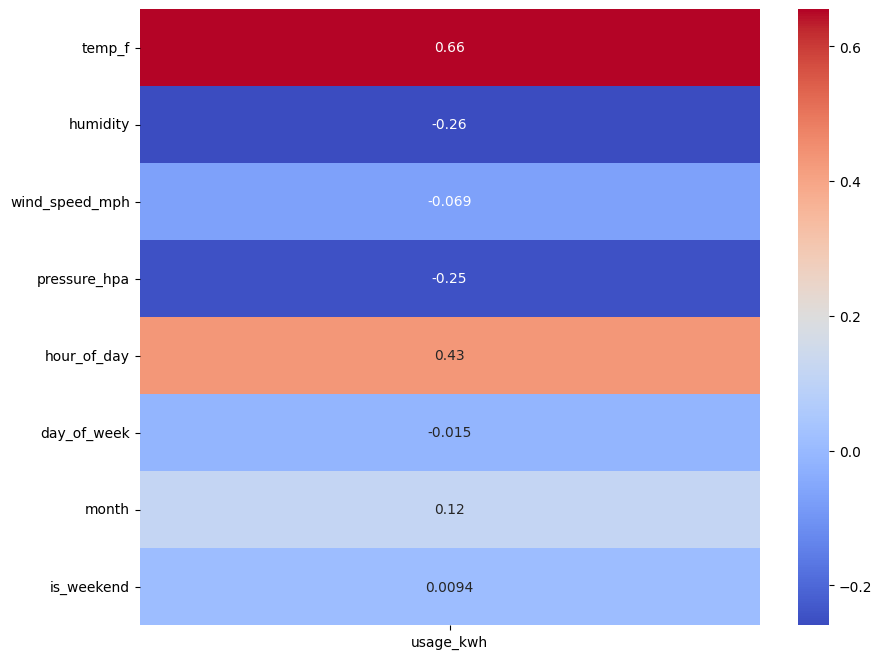

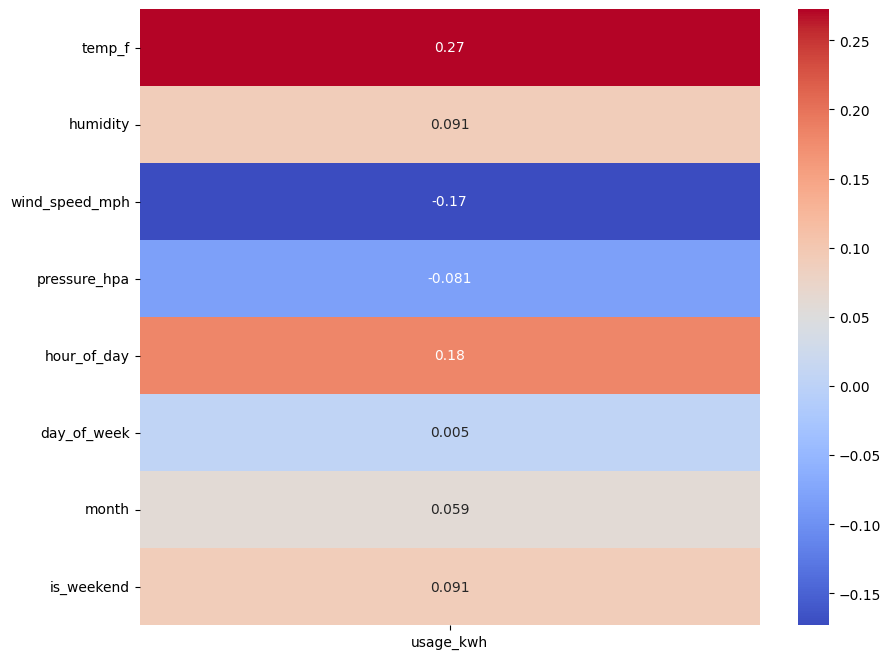

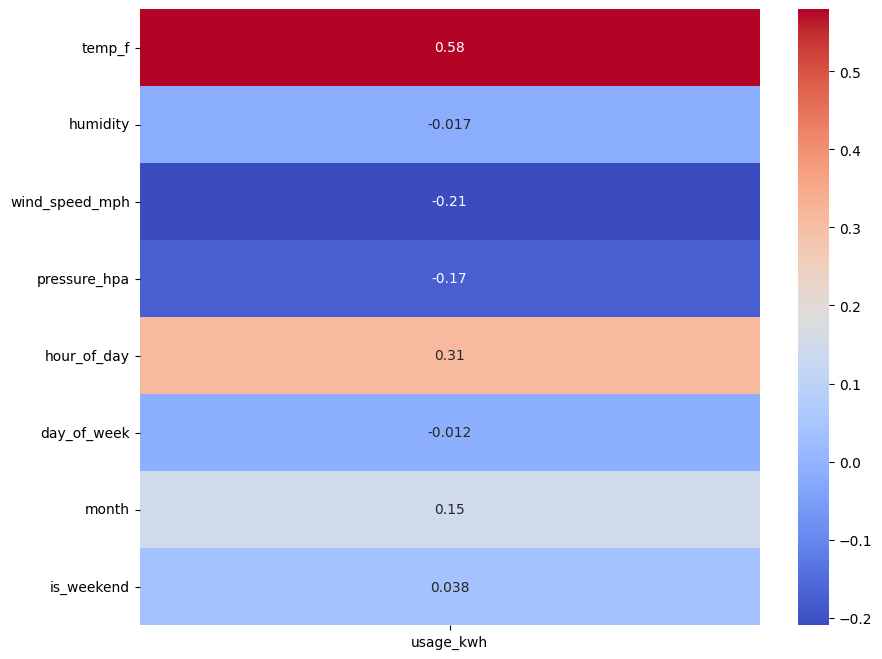

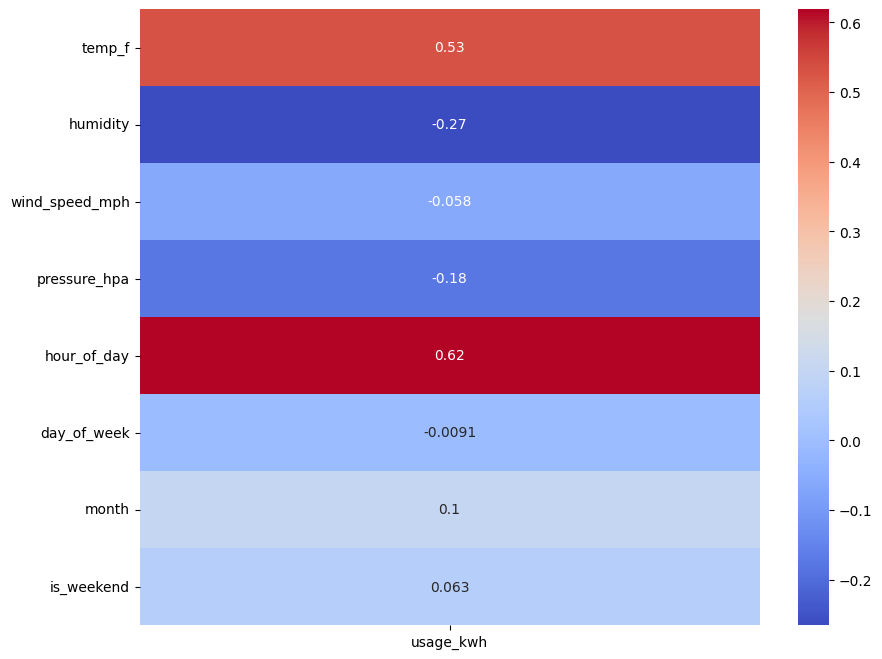

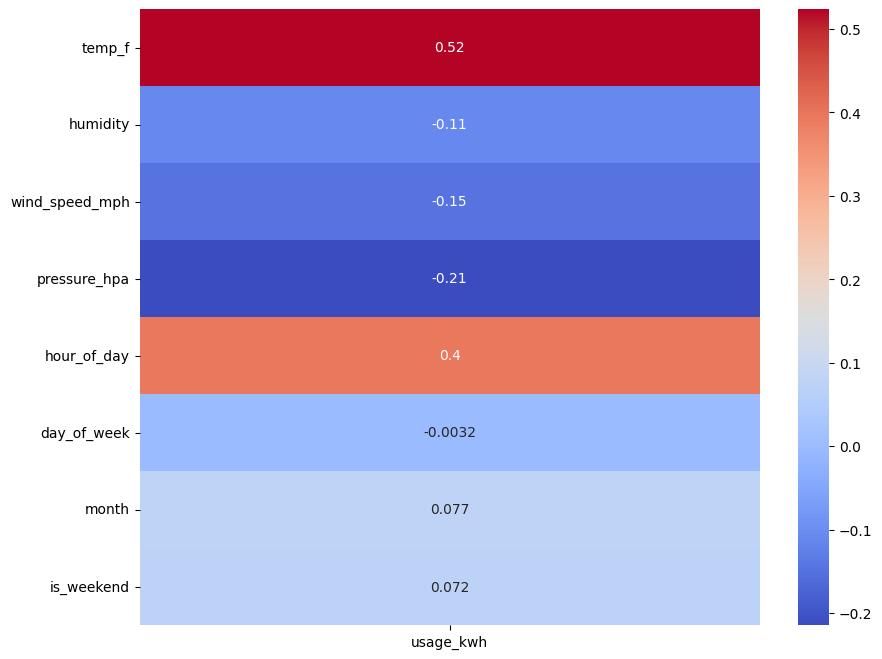

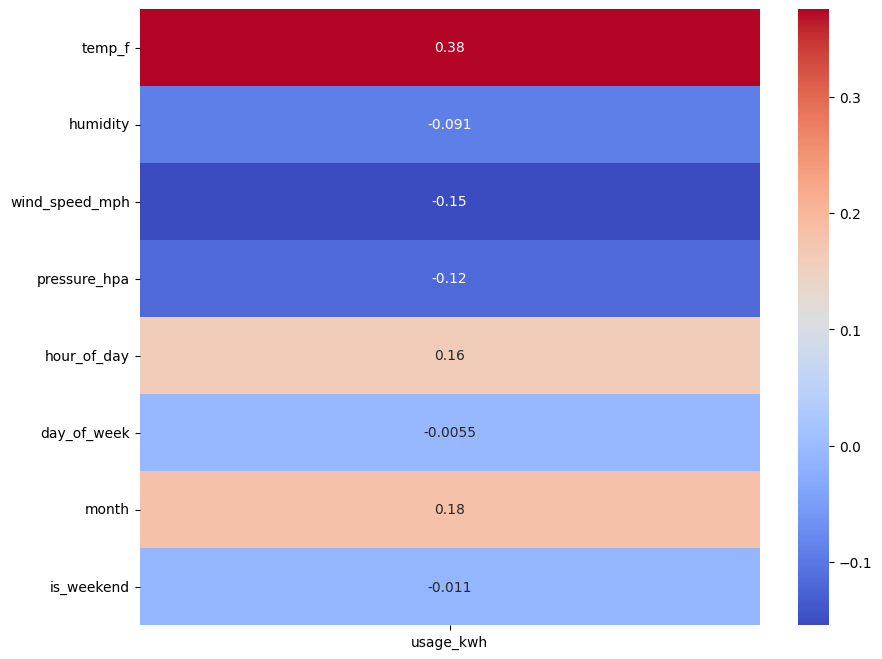

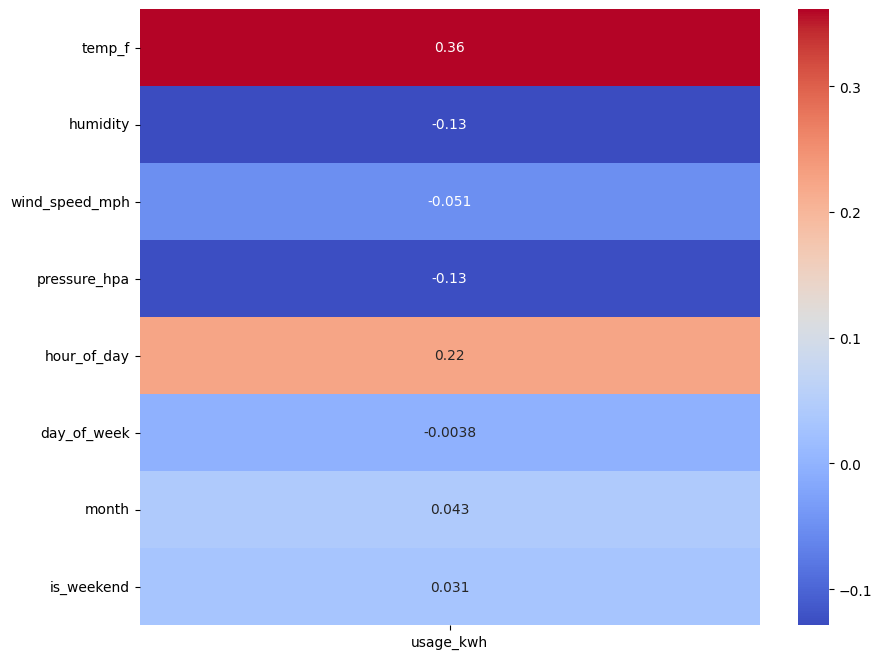

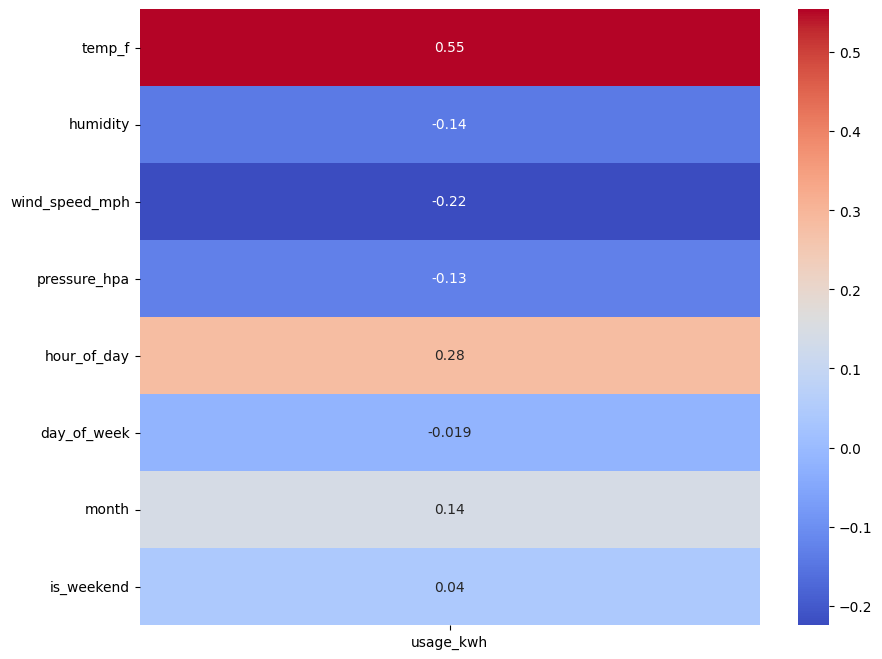

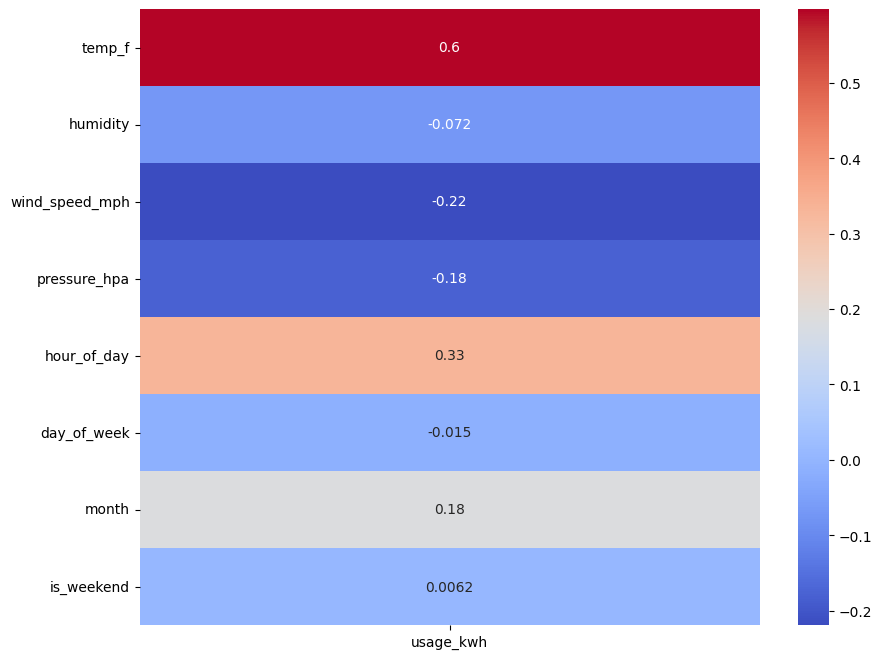

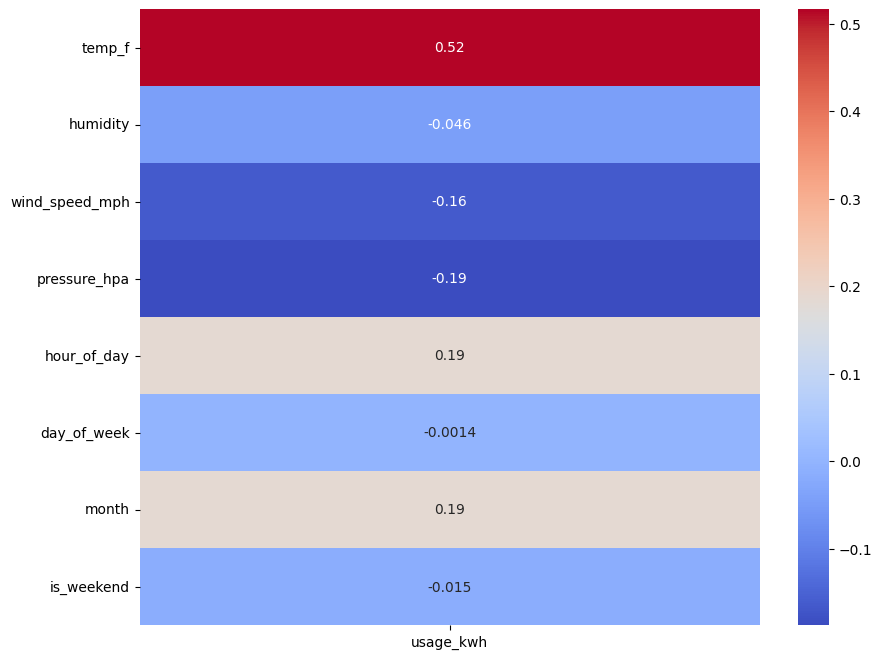

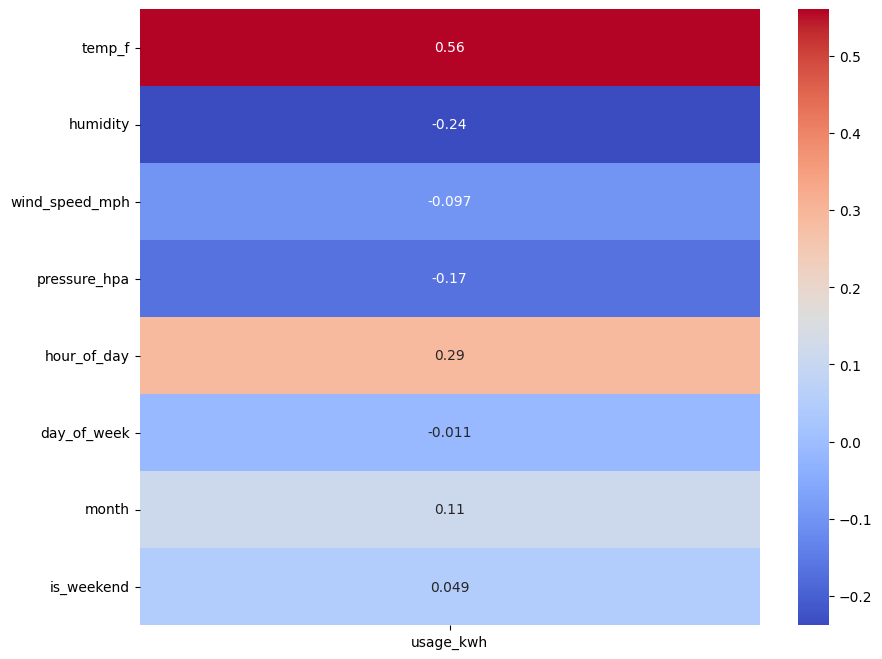

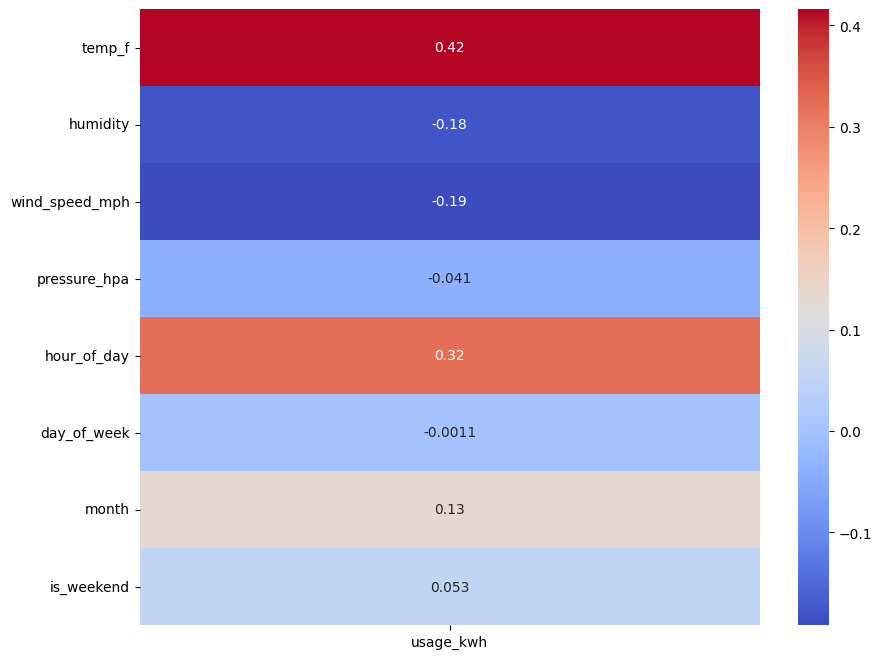

In [ ]:


features = ['usage_kwh', 'temp_f', 'humidity',
            'wind_speed_mph', 'pressure_hpa', 'hour_of_day',
            'day_of_week', 'month', 'is_weekend']
correlation={}
for esiid, data in esiid_data.items():

  corr_matrix = data[features].corr()['usage_kwh'].drop('usage_kwh')
  correlation[esiid] = corr_matrix

  plt.figure(figsize=(10,8))
  sns.heatmap(corr_matrix.to_frame(), annot=True, cmap='coolwarm') # Reshape Series to DataFrame for heatmap
  plt.show()


Looking at the correlation matrix we can see that based on our output. Energy Usage per kilo watt shows there is evidence that temperature and hour of day have a strong correlation to energy usage.

In [ ]:
def create_sequences(data, input_seq_len, output_seq_len):
    X, y = [], []
    for i in range(len(data) - input_seq_len - output_seq_len + 1):
        X.append(data[i : i + input_seq_len])                          # all 3 features
        y.append(data[i + input_seq_len : i + input_seq_len + output_seq_len, 0])  # kwh only
    return np.array(X), np.array(y)

In [ ]:
#sequences son
input_sequence_length=168
output_sequence_length=720
features = ['usage_kwh', 'temp_f', 'hour_of_day', 'day_of_week', 'month', 'is_weekend']
train={}
test={}
scalers = {}
prepared={}

for esiid, data in esiid_data.items():
  df = data[features].copy().reset_index(drop=True)

  train_len = math.ceil(len(df) * 0.8)
  train[esiid] = df[:train_len]
  test[esiid] = df[train_len:]

  scaler = MinMaxScaler(feature_range=(0,1))
  train_scaled = scaler.fit_transform(train[esiid].values)
  test_scaled = scaler.transform(test[esiid].values)

  scalers[esiid] = scaler

  x_train, y_train = create_sequences(train_scaled, input_sequence_length, output_sequence_length)
  x_test, y_test = create_sequences(test_scaled, input_sequence_length, output_sequence_length)
  prepared[esiid] = {
      'x_train': x_train,
      'y_train': y_train,
      'x_test': x_test,
      'y_test': y_test
  }
  print(f"ESIID: {esiid}")
  print(f"Train length: {len(train[esiid])}")
  print(f"Test length: {len(test[esiid])}")

ESIID: Alfa
Train length: 13976
Test length: 3494
ESIID: Bravo
Train length: 13996
Test length: 3498
ESIID: Charlie
Train length: 13996
Test length: 3498
ESIID: Delta
Train length: 13996
Test length: 3498
ESIID: Echo
Train length: 13976
Test length: 3494
ESIID: Foxtrot
Train length: 13996
Test length: 3498
ESIID: Golf
Train length: 13996
Test length: 3498
ESIID: Hotel
Train length: 13976
Test length: 3494
ESIID: India
Train length: 13996
Test length: 3498
ESIID: Juliett
Train length: 13976
Test length: 3494
ESIID: Kilo
Train length: 13996
Test length: 3498
ESIID: Lima
Train length: 13996
Test length: 3498


In [ ]:
all_train_raw_dfs = []
all_test_raw_dfs = []

for esiid in esiid_data.keys():
    # Append raw (unscaled) train and test dataframes for concatenation
    all_train_raw_dfs.append(train[esiid][features].copy())
    all_test_raw_dfs.append(test[esiid][features].copy())

# Concatenate all raw train and test dataframes
combined_train_df = pd.concat(all_train_raw_dfs, axis=0).reset_index(drop=True)
combined_test_df = pd.concat(all_test_raw_dfs, axis=0).reset_index(drop=True)

# Create and fit a single scaler for the combined 'general' dataset
general_scaler = MinMaxScaler(feature_range=(0,1))
combined_train_scaled = general_scaler.fit_transform(combined_train_df.values)
combined_test_scaled = general_scaler.transform(combined_test_df.values)

# Store the general scaler
scalers["general"] = general_scaler

# Create sequences for the 'general' model using the globally scaled data
x_train_general, y_train_general = create_sequences(combined_train_scaled, input_sequence_length, output_sequence_length)
x_test_general, y_test_general = create_sequences(combined_test_scaled, input_sequence_length, output_sequence_length)

prepared["general"] = {
    "x_train": x_train_general,
    "y_train": y_train_general,
    "x_test": x_test_general,
    "y_test": y_test_general
}

In [ ]:
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

In [ ]:
#creating RNN Model
def train_RNN(esiid,prepared):
  x_train = prepared[esiid]['x_train']
  y_train = prepared[esiid]['y_train']
  x_test = prepared[esiid]['x_test']
  y_test = prepared[esiid]['y_test']


  model = Sequential([
      Input(shape=(input_sequence_length, x_train.shape[2])),
      SimpleRNN(units=64,
                return_sequences=True),
      Dropout(0.1),
      SimpleRNN(units=32,
                return_sequences=False),
      Dropout(0.1),
      Dense(output_sequence_length)
  ])
  model.summary()
  model.compile(optimizer=Adam(clipvalue=1.0), loss='mse')

  early_stop = EarlyStopping(monitor='val_loss',
                             patience=2,
                             restore_best_weights=True,
                             verbose=1)
  model.fit(
            x_train, y_train,
            epochs=15,
            batch_size=128,
            validation_data=(x_test, y_test),
            callbacks=[early_stop]
            )
  loss=model.evaluate(x_test, y_test)
  print(f"Test Loss: {loss}")

  return model

In [ ]:
def train_LSTM(esiid,prepared):
  x_train = prepared[esiid]['x_train']
  y_train = prepared[esiid]['y_train']
  x_test = prepared[esiid]['x_test']
  y_test = prepared[esiid]['y_test']

  model = Sequential([
      Input(shape=(input_sequence_length, x_train.shape[2])),
      LSTM(50,
           return_sequences=True,
           input_shape=(x_train.shape[1],1),
           kernel_regularizer=l2(0.001),
           recurrent_regularizer=l2(0.001)),
      Dropout(0.1),
      LSTM(25,
           return_sequences=False,
           kernel_regularizer=l2(0.001),
           recurrent_regularizer=l2(0.001)),
      Dropout(0.1),
      Dense(output_sequence_length)
  ])

  model.summary()
  model.compile(optimizer=Adam(clipvalue=1.0), loss='mse')

  early_stop = EarlyStopping(monitor='val_loss',
                             patience=2,
                             restore_best_weights=True,
                             verbose=1)
  model.fit(
      x_train,
      y_train,
      validation_data=(x_test, y_test),
      epochs=15, batch_size=128,
      callbacks=[early_stop]
  )
  loss=model.evaluate(x_test, y_test)
  print(f"Test Loss: {loss}")
  return model

In [ ]:
def train_GRU(esiid, prepared):
  x_train = prepared[esiid]['x_train']
  y_train = prepared[esiid]['y_train']
  x_test = prepared[esiid]['x_test']
  y_test = prepared[esiid]['y_test']

  model = Sequential([
      Input(shape = (input_sequence_length, x_train.shape[2])),
      GRU(units=50,
          return_sequences=True,
          kernel_regularizer=l2(0.001),
          recurrent_regularizer=l2(0.001)
      ),
      Dropout(0.1),
      GRU(units=25,
          return_sequences=False,
          kernel_regularizer=l2(0.001),
          recurrent_regularizer=l2(0.001)
      ),
      Dropout(0.1),
      Dense(output_sequence_length)
  ])
  model.summary()
  model.compile(optimizer=SGD(
                        learning_rate=0.01,
                        decay = 1e-7,
                        momentum=0.9,
                        nesterov=False),
                loss='mean_squared_error'
                )

  early_stop = EarlyStopping(monitor='val_loss',
                             patience=2,
                             restore_best_weights=True,
                             verbose=1)
  model.fit(x_train,
            y_train,
            validation_data=(x_test, y_test),
            epochs=15,
            batch_size=128,
            callbacks = [early_stop]
            )
  loss = model.evaluate(x_test, y_test)
  print(f"Test Loss: {loss}")
  return model

In [ ]:
def predict(model, x_test, scaler):

  predictions_scaled = model.predict(x_test)

  num_features = scaler.n_features_in_
  arr_flat = predictions_scaled.reshape(-1)

  pad = np.zeros((len(arr_flat), num_features))
  pad[:, 0] = arr_flat

  predictions = scaler.inverse_transform(pad)[:,0]

  return predictions.reshape(predictions_scaled.shape)

In [ ]:
RNN_model={}
LSTM_model={}
GRU_model={}


In [ ]:
for esiid in esiid_data.keys():
  print(f"Training RNN Model for {esiid}")
  RNN_model[esiid] = train_RNN(esiid, prepared)

  print(f"Training LSTM Model for {esiid}")
  LSTM_model[esiid] = train_LSTM(esiid, prepared)

  print(f"Training GRU Model for {esiid}")
  GRU_model[esiid] = train_GRU(esiid, prepared)
  print(f"Finished Training {esiid}")
  print("\n")



Training RNN Model for Alfa


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 168, 64)        │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 720)            │        23,760 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,408 (122.69 KB)

 Trainable params: 31,408 (122.69 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_22 (GRU)                    │ (None, 168, 50)        │         8,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 168, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_23 (GRU)                    │ (None, 25)             │         5,775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 720)            │        18,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,195 (129.67 KB)

 Trainable params: 33,195 (129.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.2220 - val_loss: 0.2798
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.2123 - val_loss: 0.2688
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.2031 - val_loss: 0.2582
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1942 - val_loss: 0.2476
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1854 - val_loss: 0.2369
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1766 - val_loss: 0.2258
Epoch 7/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1678 - val_loss: 0.2142
Epoch 8/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1590 - val_loss: 0.2024
Epoch 9/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1503 - val_loss: 0.1905
Epoch 10/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1419 - val_loss: 0.1789
Epoch 11/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1340 - val_loss: 0.1679
Epoch 12/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
print("Training General Model\nPlease Wait...")
print("[1/3] Training RNN")
RNN_model["general"] = train_RNN("general", prepared)

print("[2/3] Training LSTM")
LSTM_model["general"] = train_LSTM("general", prepared)

print("[3/3] Training GRU")
GRU_model["general"] = train_GRU("general", prepared)

print("Finished Training General Model")

Training General Model
Please Wait...
[1/3] Training RNN


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_24 (SimpleRNN)       │ (None, 168, 64)        │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_25 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_73 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 720)            │        23,760 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,408 (122.69 KB)

 Trainable params: 31,408 (122.69 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_24 (GRU)                    │ (None, 168, 50)        │         8,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 168, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_25 (GRU)                    │ (None, 25)             │         5,775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 720)            │        18,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,195 (129.67 KB)

 Trainable params: 33,195 (129.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - loss: 0.1380 - val_loss: 0.1228
Epoch 2/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0855 - val_loss: 0.0803
Epoch 3/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0552 - val_loss: 0.0557
Epoch 4/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0379 - val_loss: 0.0416
Epoch 5/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0278 - val_loss: 0.0334
Epoch 6/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0219 - val_loss: 0.0286
Epoch 7/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0184 - val_loss: 0.0258
Epoch 8/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0163 - val_loss: 0.0241
Epoch 9/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0151 - val_loss: 0.0231
Epoch 10/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0144 - val_loss: 0.0225
Epoch 11/15
1305/1305 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0140 - val_loss: 0.0222
Epoch 12

In [ ]:
def evaluate_model(model, esiid, prepared, scalers):
    x_test  = prepared[esiid]['x_test']
    y_test  = prepared[esiid]['y_test']
    scaler  = scalers[esiid]

    pred = model.predict(x_test, verbose=0)

    # squeeze out any extra dimensions first
    pred   = pred.squeeze()    # (samples, output_sequence_length)
    y_test = y_test.squeeze()  # ensure same shape

    # flatten to 1D
    pred_flat   = pred.reshape(-1, 1)
    actual_flat = y_test.reshape(-1, 1)

    # pad to `len(features)` cols for inverse transform, take col 0 (kwh)
    def inverse_kwh(arr):
        # The scaler was fitted on `len(features)` columns.
        # We need to pad the single kwh column to `len(features)` columns
        # for inverse transformation.
        num_features = len(features)
        padded = np.concatenate([arr, np.zeros((len(arr), num_features - 1))], axis=1)
        return scaler.inverse_transform(padded)[:, 0]

    pred_kwh   = inverse_kwh(pred_flat)
    actual_kwh = inverse_kwh(actual_flat)

    mape = np.mean(np.abs(
        (actual_kwh - pred_kwh) / np.where(actual_kwh == 0, 1, actual_kwh)
    )) * 100

    return {
        'mae':  mean_absolute_error(actual_kwh, pred_kwh),
        'mse':  np.sqrt(mean_squared_error(actual_kwh, pred_kwh)),
        'mape': mape
    }

In [ ]:
metrics={}

In [ ]:
for esiid in esiid_data.keys():
  metrics[esiid] = {
      'rnn':  evaluate_model(RNN_model[esiid],  esiid, prepared, scalers),
      'lstm': evaluate_model(LSTM_model[esiid], esiid, prepared, scalers),
      'gru':  evaluate_model(GRU_model[esiid],  esiid, prepared, scalers),
    }

for esiid, results in metrics.items():
  print(f"\n{esiid}")
  for model_name, result in results.items():
    print(f"{model_name}: {result}")


Alfa
rnn: {'mae': 0.706639139150832, 'mse': np.float64(0.9558030472300311), 'mape': np.float64(42.869491484357155)}
lstm: {'mae': 1.2902215982030543, 'mse': np.float64(1.5691748395372171), 'mape': np.float64(100.44488678533092)}
gru: {'mae': 1.7066584952478994, 'mse': np.float64(2.1760456934445873), 'mape': np.float64(66.17300195418481)}

Bravo
rnn: {'mae': 0.8451134679982414, 'mse': np.float64(1.1305022889974983), 'mape': np.float64(56.88692458654786)}
lstm: {'mae': 1.2728117228926839, 'mse': np.float64(1.541965115440328), 'mape': np.float64(73.49542319987668)}
gru: {'mae': 1.310512330607325, 'mse': np.float64(1.7583132427422017), 'mape': np.float64(54.859118242447934)}

Charlie
rnn: {'mae': 1.38074452644623, 'mse': np.float64(1.8172298084798015), 'mape': np.float64(32.4538799848292)}
lstm: {'mae': 2.2220795538644493, 'mse': np.float64(2.6689664617188935), 'mape': np.float64(48.71541147663127)}
gru: {'mae': 2.9045309725074824, 'mse': np.float64(3.7123208016147453), 'mape': np.float64

In [ ]:
metrics["general"] = {
      'rnn':  evaluate_model(RNN_model["general"],  "general", prepared, scalers),
      'lstm': evaluate_model(LSTM_model["general"], "general", prepared, scalers),
      'gru':  evaluate_model(GRU_model["general"],  "general", prepared, scalers),
    }


In [ ]:
print("General")
for model_name, results in metrics["general"].items():
  print(f"{model_name}: {results}")

General
rnn: {'mae': 1.8209266377833182, 'mse': np.float64(2.7382861096965665), 'mape': np.float64(79.73956558983073)}
lstm: {'mae': 2.2326125217492128, 'mse': np.float64(3.081132619186726), 'mape': np.float64(101.90961722236092)}
gru: {'mae': 2.8182140364651236, 'mse': np.float64(4.088413310583192), 'mape': np.float64(103.74576480628872)}


In [ ]:
best_models={}

for esiid in list(esiid_data.keys()) + ['general']:
    esiid_metrics=metrics[esiid]
    best_model_name = min(esiid_metrics, key=lambda x: esiid_metrics[x]['mae'])
    model_lookup = {"rnn": RNN_model, "lstm": LSTM_model, "gru": GRU_model}
    best_models[esiid] = {"model": model_lookup[best_model_name][esiid],
                          "model_type": best_model_name
                          }
    print(f"{esiid} best model: {best_model_name} MAE: {esiid_metrics[best_model_name]['mae']}")
  #

Alfa best model: rnn MAE: 0.706639139150832
Bravo best model: rnn MAE: 0.8451134679982414
Charlie best model: rnn MAE: 1.38074452644623
Delta best model: rnn MAE: 1.075166770983583
Echo best model: rnn MAE: 3.202932018314251
Foxtrot best model: rnn MAE: 2.611535222746816
Golf best model: rnn MAE: 1.6521973877096303
Hotel best model: rnn MAE: 1.0617104823571781
India best model: rnn MAE: 1.5148697199379653
Juliett best model: rnn MAE: 2.2034579626619646
Kilo best model: rnn MAE: 1.1863166848171895
Lima best model: rnn MAE: 0.8415298043591278
general best model: rnn MAE: 1.8209266377833182


In [ ]:
RNN_prediction = {}
LSTM_prediction = {}
GRU_prediction={}



Add code for saving models to GCS.
Add code to upload general model, and Each ESIID Model.
Upload each model by their esiid and model name.
> Add blockquote



In [ ]:
for esiid, model in LSTM_model.items():
  print(f"Esiid: {esiid} , Model Name: {model}")

Esiid: Alfa , Model Name: <Sequential name=sequential_1, built=True>
Esiid: Bravo , Model Name: <Sequential name=sequential_4, built=True>
Esiid: Charlie , Model Name: <Sequential name=sequential_7, built=True>
Esiid: Delta , Model Name: <Sequential name=sequential_10, built=True>
Esiid: Echo , Model Name: <Sequential name=sequential_13, built=True>
Esiid: Foxtrot , Model Name: <Sequential name=sequential_16, built=True>
Esiid: Golf , Model Name: <Sequential name=sequential_19, built=True>
Esiid: Hotel , Model Name: <Sequential name=sequential_22, built=True>
Esiid: India , Model Name: <Sequential name=sequential_25, built=True>
Esiid: Juliett , Model Name: <Sequential name=sequential_28, built=True>
Esiid: Kilo , Model Name: <Sequential name=sequential_31, built=True>
Esiid: Lima , Model Name: <Sequential name=sequential_34, built=True>
Esiid: general , Model Name: <Sequential name=sequential_37, built=True>


In [ ]:
#upload general model to gcs
gcs_path = f"gs://smartwatts-models-final/models"
for esiid, model in RNN_model.items():
  print(f"saving {model}")
  model.save(f"{gcs_path}/RNN/{esiid}.keras")
for esiid, model in LSTM_model.items():
  print(f"saving {model}")
  model.save(f"{gcs_path}/LSTM/{esiid}.keras")
for esiid, model in GRU_model.items():
  print(f"saving {model}")
  model.save(f"{gcs_path}/GRU/{esiid}.keras")

saving <Sequential name=sequential, built=True>
saving <Sequential name=sequential_3, built=True>
saving <Sequential name=sequential_6, built=True>
saving <Sequential name=sequential_9, built=True>
saving <Sequential name=sequential_12, built=True>
saving <Sequential name=sequential_15, built=True>
saving <Sequential name=sequential_18, built=True>
saving <Sequential name=sequential_21, built=True>
saving <Sequential name=sequential_24, built=True>
saving <Sequential name=sequential_27, built=True>
saving <Sequential name=sequential_30, built=True>
saving <Sequential name=sequential_33, built=True>
saving <Sequential name=sequential_36, built=True>
saving <Sequential name=sequential_1, built=True>
saving <Sequential name=sequential_4, built=True>
saving <Sequential name=sequential_7, built=True>
saving <Sequential name=sequential_10, built=True>
saving <Sequential name=sequential_13, built=True>
saving <Sequential name=sequential_16, built=True>
saving <Sequential name=sequential_19, b

In [ ]:
all_metrics=[]
predictions = {
    "rnn": RNN_prediction,
    "lstm": LSTM_prediction,
    "gru": GRU_prediction
}

models={
    "rnn": RNN_model,
    "lstm": LSTM_model,
    "gru": GRU_model
}
client = bigquery.Client(project="smartwatts-project")


In [ ]:

def upload_dataset_to_BQ(df, table_name):
  job=client.load_table_from_dataframe(df,table_name)
  job.result()

In [ ]:
for model_name, model_dict in models.items():
    for esiid in model_dict.keys():
        print(f"saving metrics for {esiid}")
        all_metrics.append({
            "run_date": pd.Timestamp.utcnow(),
            "model_type": model_name.upper(),
            "esiid": esiid,
            "mae": metrics[esiid][model_name]["mae"],
            "mse": metrics[esiid][model_name]["mse"],
            "mape": metrics[esiid][model_name]["mape"],
            "input_hours": input_sequence_length,
            "output_hours": output_sequence_length,
        })
metrics_df = pd.DataFrame(all_metrics)

saving metrics for Alfa
saving metrics for Bravo
saving metrics for Charlie
saving metrics for Delta
saving metrics for Echo
saving metrics for Foxtrot
saving metrics for Golf
saving metrics for Hotel
saving metrics for India
saving metrics for Juliett
saving metrics for Kilo
saving metrics for Lima
saving metrics for general
saving metrics for Alfa
saving metrics for Bravo
saving metrics for Charlie
saving metrics for Delta
saving metrics for Echo
saving metrics for Foxtrot
saving metrics for Golf
saving metrics for Hotel
saving metrics for India
saving metrics for Juliett
saving metrics for Kilo
saving metrics for Lima
saving metrics for general
saving metrics for Alfa
saving metrics for Bravo
saving metrics for Charlie
saving metrics for Delta
saving metrics for Echo
saving metrics for Foxtrot
saving metrics for Golf
saving metrics for Hotel
saving metrics for India
saving metrics for Juliett
saving metrics for Kilo
saving metrics for Lima
saving metrics for general


In [ ]:
all_predictions = []

for esiid, best in best_models.items():
    pred = predict(
        model=best["model"],
        x_test=prepared[esiid]["x_test"],
        scaler=scalers[esiid]
    )
    pred_flat = pred[0]
    start_time = pd.Timestamp.utcnow().floor('h')
    timestamps = pd.date_range(start=start_time, periods=len(pred_flat), freq='h')

    all_predictions.append(pd.DataFrame({
        "prediction_time": timestamps,
        "model_type": best["model_type"].upper(),
        "esiid": esiid,
        "predicted_kwh": pred_flat
    }))

predictions_df = pd.concat(all_predictions)

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
1284/1284 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step


Only run predict on whole dataset to verify we are running normally. Once Completed we find the best model to predict on.

In [ ]:
dataset_id = "smartwatts-project.forecasting"
dataset=bigquery.Dataset(dataset_id)
dataset.location="US"

client.create_dataset(dataset,timeout=30,exists_ok=True)
print("Created dataset {}.{}".format(client.project, dataset.dataset_id))

Created dataset smartwatts-project.forecasting


In [ ]:
upload_dataset_to_BQ(metrics_df, "smartwatts-project.forecasting.model_metrics")
print("Finished uploading metrics\nUploading predictions")
upload_dataset_to_BQ(predictions_df, "smartwatts-project.forecasting.model_predictions")
print("Finished uploading Predictions")

Finished uploading metrics
Uploading predictions
Finished uploading Predictions
